# 载入模块

In [1]:
import numpy as np
import xarray as xr
from netCDF4 import Dataset
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
import metpy
import project
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import os

from wrf import getvar, interplevel
import metpy.calc as mpcalc
from metpy.interpolate import cross_section

# 读取数据和投影

In [2]:
file_path = 'wrf_data\index_1\wrfout_d01_2025-07-24_18_00_00.nc'
ncfile = Dataset(file_path)
wrf_ds = xr.open_dataset(file_path)
crs = project.get_projection(wrf_ds)

# 处理文件名

In [3]:
filename = file_path.split('\\')[-1].split('/')[-1]
parts = filename.split('_')
month_day = parts[2][5:] 
hour = parts[3]           
result = f"{month_day}_{hour}"

# 读取变量

In [ ]:
pres = getvar(ncfile, "pressure")      # 全层气压 (hPa)
z = getvar(ncfile, "z", units="dm")    # 全层位势高度 (dm)
ua = getvar(ncfile, "ua")              # 全层 U 风分量
va = getvar(ncfile, "va")              # 全层 V 风分量

wa = getvar(ncfile, "wa") 
q = getvar(ncfile, "QVAPOR")    # 混合比
rh = getvar(ncfile, "rh")  


q_700 = interplevel(q, pres, 700)  # 700 hPa
ua_700 = interplevel(ua, pres, 700)
va_700 = interplevel(va, pres, 700)

lon_2d = q_700['XLONG']
lat_2d = q_700['XLAT']

# 计算水汽通量

In [6]:
g = 9.81

vlocity_700 = np.sqrt(ua_700**2 + va_700**2)

qflux_700 = (q_700 * vlocity_700)/g
qflux_700 = qflux_700 * 1000

# 绘图

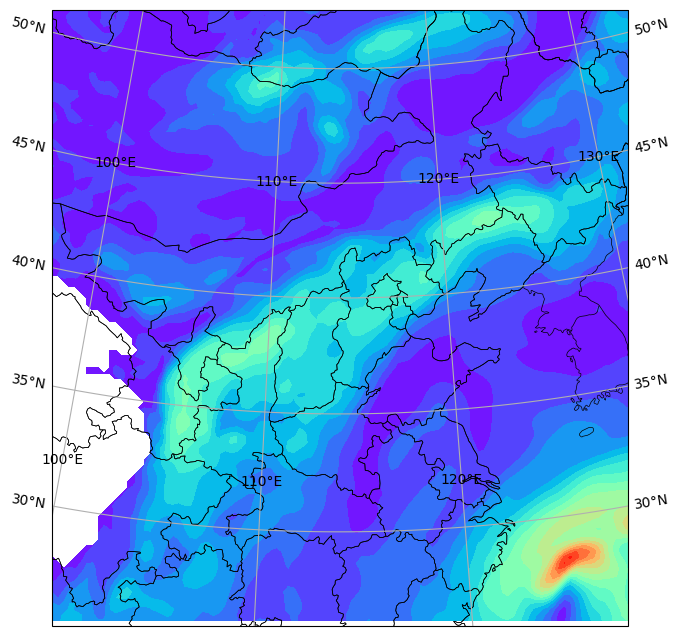

In [ ]:
fig,ax = plt.subplots(figsize=(12,8),subplot_kw={'projection':crs},dpi=100)
project.plot_background(lon_2d.min(),lon_2d.max(),lat_2d.min(),lat_2d.max(),ax)


levels = np.arange(0,35,2)
ax.contourf(lon_2d,lat_2d,qflux_700,cmap='rainbow',levels=levels,transform=ccrs.PlateCarree())
ax.set_extent([lon_2d[0,0], lon_2d[0,-1], lat_2d[0,0], lat_2d[-1,0]], crs=ccrs.PlateCarree())